In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import pmdarima as pmd
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import r2_score

In [4]:
df = pd.read_csv('example_retail_sales.csv')
df.head()

,ds,y
0,1992-01-01,146376
1,1992-02-01,147079
2,1992-03-01,159336
3,1992-04-01,163669
4,1992-05-01,170068


In [5]:
m = Prophet(seasonality_mode="additive")
m.fit(df)

11:52:02 - cmdstanpy - INFO - Chain [1] start processing
11:52:02 - cmdstanpy - INFO - Chain [1] done processing


In [6]:
future = m.make_future_dataframe(periods=12, freq='MS')
forecast = m.predict(future)

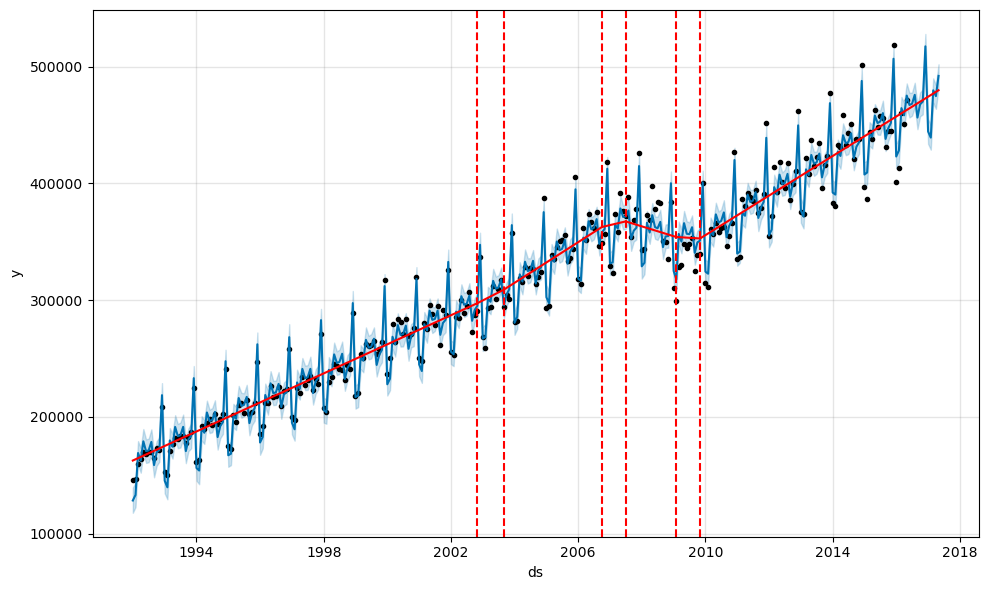

In [7]:
fig = m.plot(forecast);
a = add_changepoints_to_plot(fig.gca(), m, forecast)

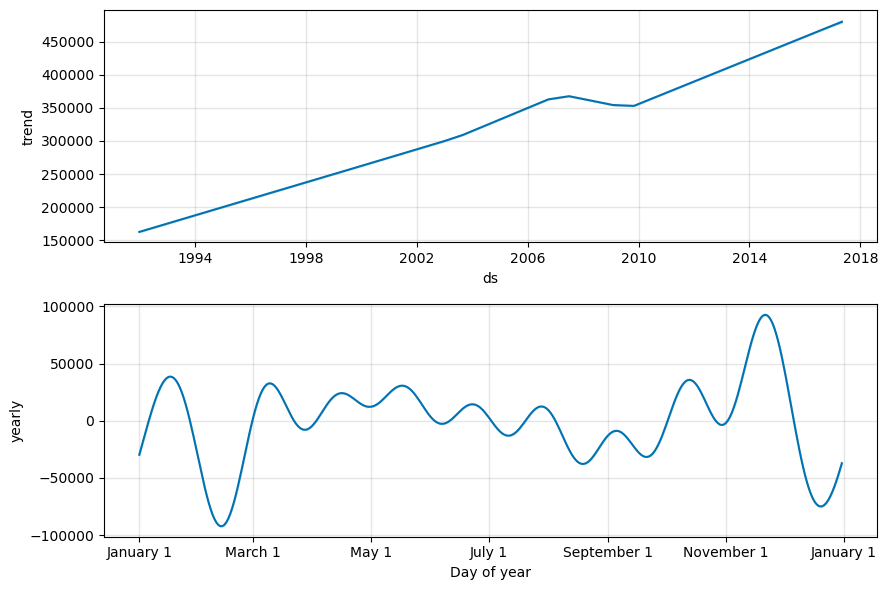

In [8]:
m.plot_components(forecast);

In [9]:
# Supposons que 'forecast' est le DataFrame de prévisions généré par le modèle Prophet
y_pred = forecast['yhat']

In [10]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1992-01-01,162684.280977,117938.185474,139509.436888,162684.280977,162684.280977,-34235.732160,-34235.732160,-34235.732160,-34235.732160,-34235.732160,-34235.732160,0.0,0.0,0.0,128448.548817
1,1992-02-01,163738.429506,122857.989146,143910.213964,163738.429506,163738.429506,-30525.501333,-30525.501333,-30525.501333,-30525.501333,-30525.501333,-30525.501333,0.0,0.0,0.0,133212.928173
2,1992-03-01,164724.568452,159203.942473,179368.469533,164724.568452,164724.568452,4417.848692,4417.848692,4417.848692,4417.848692,4417.848692,4417.848692,0.0,0.0,0.0,169142.417144
3,1992-04-01,165778.716981,152241.171995,173487.723652,165778.716981,165778.716981,-3177.578486,-3177.578486,-3177.578486,-3177.578486,-3177.578486,-3177.578486,0.0,0.0,0.0,162601.138494
4,1992-05-01,166798.860718,168982.397656,189676.569261,166798.860718,166798.860718,12340.056279,12340.056279,12340.056279,12340.056279,12340.056279,12340.056279,0.0,0.0,0.0,179138.916997


In [11]:
y = df['y']

In [12]:
print(r2_score(y,y_pred[:293]))

0.9912265838452976


In [13]:
def rmse(t, y):
    return np.sqrt(np.mean((t - y)**2))

In [14]:
print("RMSE:", rmse(y, y_pred[:293]))

RMSE: 8049.447152534873


In [15]:
m = Prophet(seasonality_mode="multiplicative")
m.fit(df)

11:52:04 - cmdstanpy - INFO - Chain [1] start processing
11:52:04 - cmdstanpy - INFO - Chain [1] done processing


In [16]:
future = m.make_future_dataframe(periods=12, freq='MS')
forecast = m.predict(future)

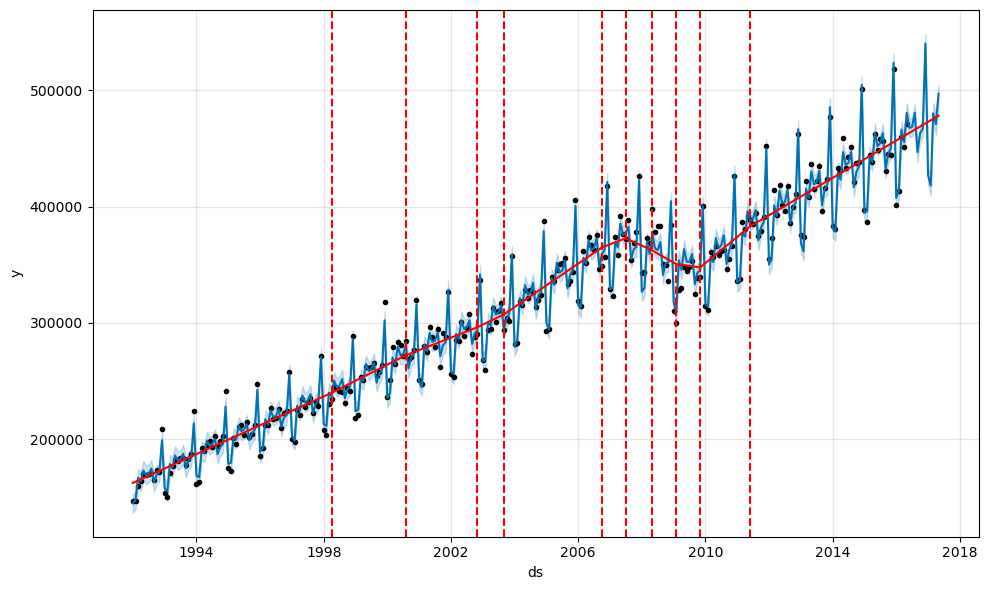

In [17]:
fig = m.plot(forecast);
a = add_changepoints_to_plot(fig.gca(), m, forecast)

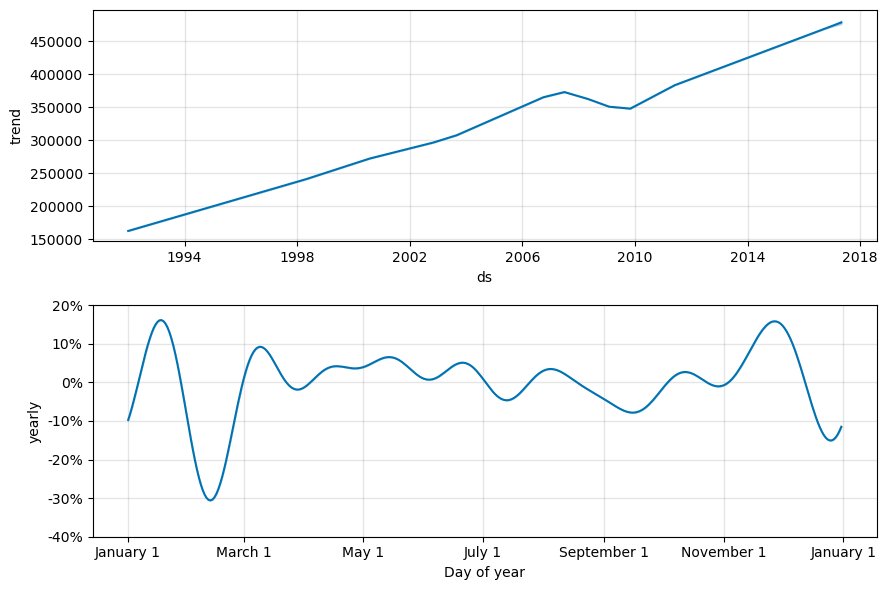

In [18]:
m.plot_components(forecast);

In [19]:
y2_pred = forecast['yhat']

In [20]:
print(r2_score(y,y2_pred[:293]))

0.9949057799185985


In [21]:
print("RMSE:", rmse(y, y2_pred[:293]))

RMSE: 6133.671886243366


# Auto_ARIMA

In [22]:
df.head()

,ds,y
0,1992-01-01,146376
1,1992-02-01,147079
2,1992-03-01,159336
3,1992-04-01,163669
4,1992-05-01,170068


In [23]:
df.set_index(['ds'], inplace=True)

In [24]:
df.head()

,y
ds,
1992-01-01,146376
1992-02-01,147079
1992-03-01,159336
1992-04-01,163669
1992-05-01,170068


In [25]:
df.shape

(293, 1)

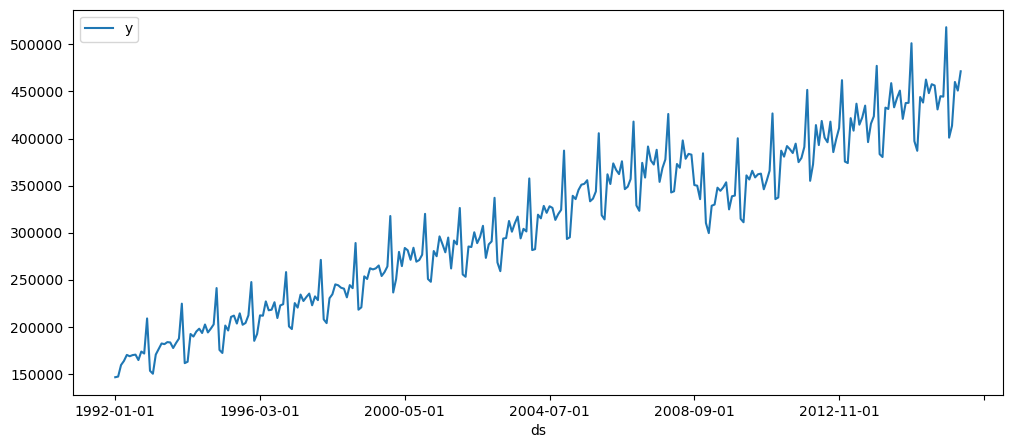

In [26]:
df.plot(figsize=(12,5));

In [27]:
Ntest = 30
train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

In [28]:
model = pmd.auto_arima(train, error_action='ignore', trace=True, supress_warning=True, seasonal=True, m=12)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=5467.841, Time=1.61 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=5481.402, Time=0.06 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=5512.609, Time=0.36 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=5413.400, Time=0.34 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=5626.907, Time=0.05 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=5412.030, Time=0.11 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=5413.510, Time=0.27 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=5415.373, Time=0.44 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=5577.880, Time=0.29 sec
 ARIMA(0,0,2)(0,1,0)[12] intercept   : AIC=5401.513, Time=0.15 sec
 ARIMA(0,0,2)(1,1,0)[12] intercept   : AIC=5402.540, Time=0.34 sec
 ARIMA(0,0,2)(0,1,1)[12] intercept   : AIC=5402.252, Time=0.45 sec
 ARIMA(0,0,2)(1,1,1)[12] intercept   : AIC=5404.090, Time=0.57 sec
 ARIMA(1,0,2)(0,1,0)[12] intercept   : AIC=5387.852, Time=0.79 sec
 ARIMA(1,0,2)(1,1,0

In [29]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  263
Model:             SARIMAX(1, 0, 2)x(1, 1, [1], 12)   Log Likelihood               -2678.613
Date:                              Sat, 21 Oct 2023   AIC                           5371.227
Time:                                      11:52:38   BIC                           5395.905
Sample:                                  01-01-1992   HQIC                          5381.158
                                       - 11-01-2013                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1255.9903    610.945      2.056      0.040      58.560    2453.420
ar.L1          0.8779      0.044     19.888      0.000       0.791       0.964
ma.L1         -0.5011      0.050     -9.941      0.000      -0.600      -0.402
ma.L2         -0.2185      0.054     -4.049      0.000      -0.324      -0.113
ar.S.L12       0.1545      0.134      1.154      0.248      -0.108       0.417
ma.S.L12      -0.3989      0.152     -2.625      0.009      -0.697      -0.101
sigma2      1.086e+08      0.013   8.54e+09      0.000    1.09e+08    1.09e+08
===================================================================================
Ljung-Box (L1) (Q):                  36.19   Jarque-Bera (JB):              2095.24
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.26   Skew:                            -2.44
Prob(H) (two-sided):                  0.30   Kurtosis:                        16.29
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.76e+25. Standard errors may be unstable.
"""

In [30]:
test_pred, confint = model.predict(n_periods=Ntest, return_conf_int=True)

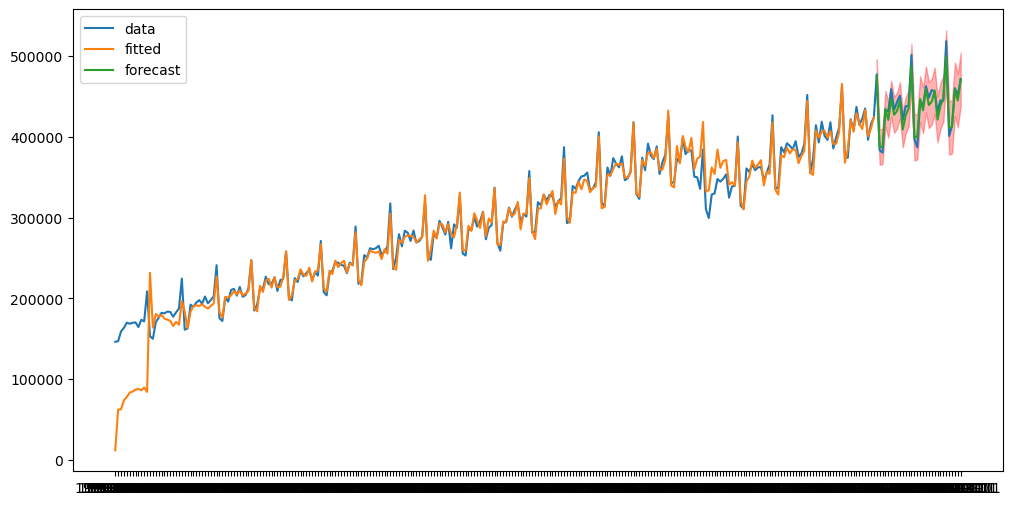

In [31]:
train_pred = model.predict_in_sample(start=0, end=-1)

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(df.index, df['y'], label='data')
ax.plot(train.index, train_pred, label='fitted')
ax.plot(test.index, test_pred, label='forecast')
ax.fill_between(test.index, \
               confint[:,0], confint[:,1], \
               color='red', alpha=0.3)
ax.legend();

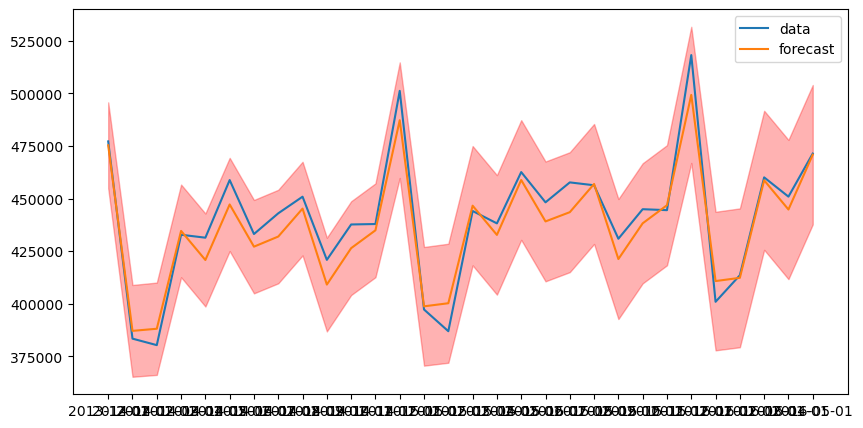

In [32]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(test.index, test['y'], label='data')
ax.plot(test.index, test_pred, label='forecast')
ax.fill_between(test.index, \
               confint[:,0], confint[:,1], \
               color='red', alpha=0.3)
ax.legend();

In [33]:
print(r2_score(test['y'], test_pred))

0.9254864202034202


In [34]:
def rmse(t, y):
    return np.sqrt(np.mean((t - y)**2))

In [35]:
print("RMSE:", rmse(test_pred, test['y']))

RMSE: nan


In [36]:
test_pred, confint = model.predict(n_periods=40, return_conf_int=True)

In [37]:
confint[-11:]

array([[437748.24089401, 504023.73398605],
       [418086.28413403, 484409.12673662],
       [422403.18910369, 488762.50112606],
       [435836.33842405, 502223.74391614],
       [400184.23399292, 466593.28313456],
       [417126.2271322 , 483551.95231635],
       [425739.04100794, 492177.61563428],
       [474958.74583994, 547954.12585369],
       [385921.79981094, 459891.57076196],
       [387423.23141125, 461509.23573714],
       [433757.61548224, 507933.07709304]])

In [38]:
test_pred

2013-12-01    475345.575142
2014-01-01    387095.955630
2014-02-01    388109.137259
2014-03-01    434639.284965
2014-04-01    420799.127620
2014-05-01    447217.863356
2014-06-01    427145.819822
2014-07-01    431954.654154
2014-08-01    445246.950788
2014-09-01    409112.379379
2014-10-01    426435.263655
2014-11-01    434923.913594
2014-12-01    487291.228824
2015-01-01    398773.590510
2015-02-01    400238.709660
2015-03-01    446630.416549
2015-04-01    432737.316859
2015-05-01    458850.975590
2015-06-01    439149.430316
2015-07-01    443543.410845
2015-08-01    456965.863832
2015-09-01    421255.031979
2015-10-01    438252.142273
2015-11-01    446851.188391
2015-12-01    499329.407361
2016-01-01    410781.864839
2016-02-01    412326.938006
2016-03-01    458706.125454
2016-04-01    444812.635797
2016-05-01    470885.987440
2016-06-01    451247.705435
2016-07-01    455582.845115
2016-08-01    469030.041170
2016-09-01    433388.758564
2016-10-01    450339.089724
2016-11-01    458958

In [39]:
# Convertissez les index en objets de date sans fuseau horaire
df.index = pd.to_datetime(df.index).tz_localize(None)
train.index = pd.to_datetime(train.index).tz_localize(None)
test_pred.index = pd.to_datetime(test_pred.index).tz_localize(None)
test.index = pd.to_datetime(test.index).tz_localize(None)

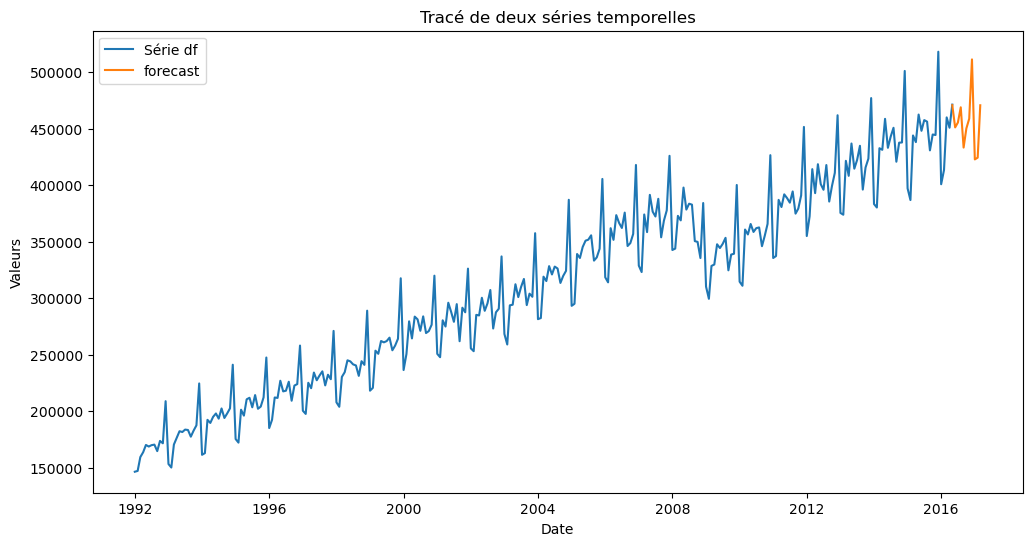

In [40]:
# Créez une figure
fig, ax = plt.subplots(figsize=(12, 6))

# Tracez la première série (df)
ax.plot(df.index, df['y'], label='Série df')

# Tracez la deuxième série (df_hat)
ax.plot(test_pred.index[-11:], test_pred[-11:], label='forecast')

# Personnalisez le graphique
ax.set_xlabel('Date')
ax.set_ylabel('Valeurs')
ax.set_title('Tracé de deux séries temporelles')
ax.legend()

# Affichez la figure
plt.show()

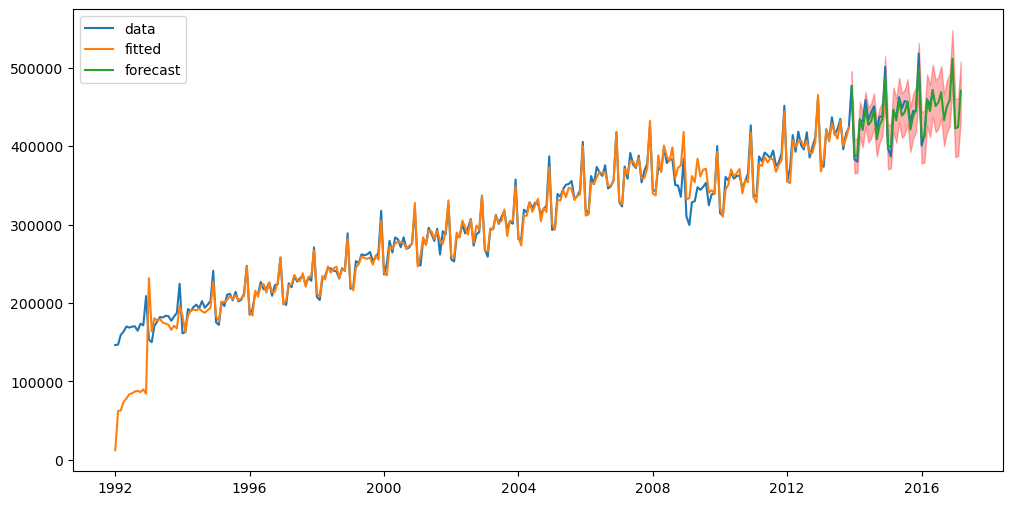

In [41]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(df.index, df['y'], label='data')
ax.plot(train.index, train_pred, label='fitted')
ax.plot(test_pred.index, test_pred, label='forecast')
ax.fill_between(test_pred.index, \
               confint[:,0], confint[:,1], \
               color='red', alpha=0.3)
ax.legend();

# ESM

In [42]:
df.index.freq = 'MS'
df.index

DatetimeIndex(['1992-01-01', '1992-02-01', '1992-03-01', '1992-04-01',
               '1992-05-01', '1992-06-01', '1992-07-01', '1992-08-01',
               '1992-09-01', '1992-10-01',
               ...
               '2015-08-01', '2015-09-01', '2015-10-01', '2015-11-01',
               '2015-12-01', '2016-01-01', '2016-02-01', '2016-03-01',
               '2016-04-01', '2016-05-01'],
              dtype='datetime64[ns]', name='ds', length=293, freq='MS')

In [43]:
train_idx = df.index <= train.index[-1]
test_idx = df.index > train.index[-1]

In [44]:
train.index.freq = 'MS'

In [45]:
hw = ExponentialSmoothing(
                        train['y'],
                        trend='add',
                        seasonal='mul',
                        seasonal_periods=12,
                        initialization_method='heuristic',
                        #use_boxcox=True
                        )
res_hw = hw.fit()

C:\Users\pc\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:915: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [46]:
df.loc[train_idx, 'HoltWinterTrain'] = res_hw.fittedvalues

In [47]:
df.loc[test_idx, 'HoltWinterTest'] = res_hw.forecast(Ntest)

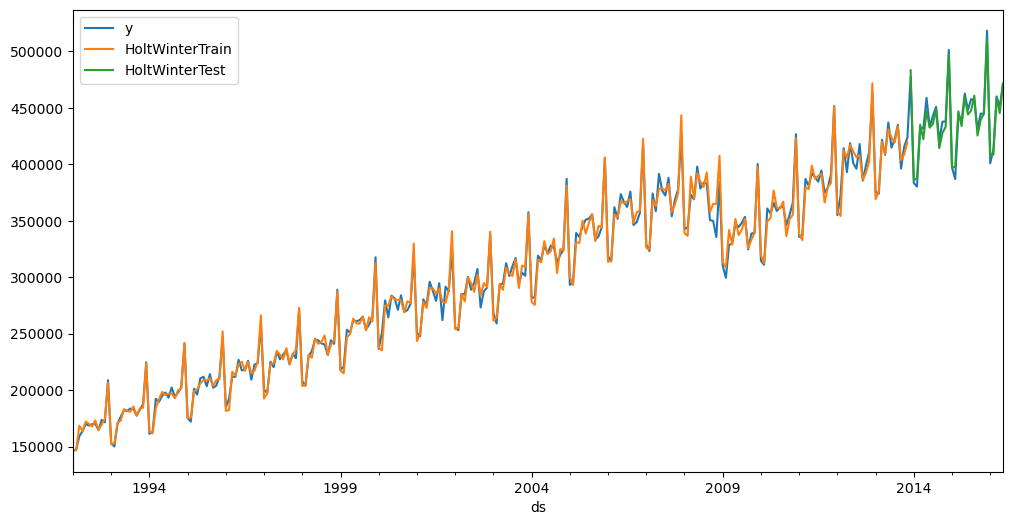

In [48]:
df[['y','HoltWinterTrain','HoltWinterTest']].plot(figsize=(12,6));

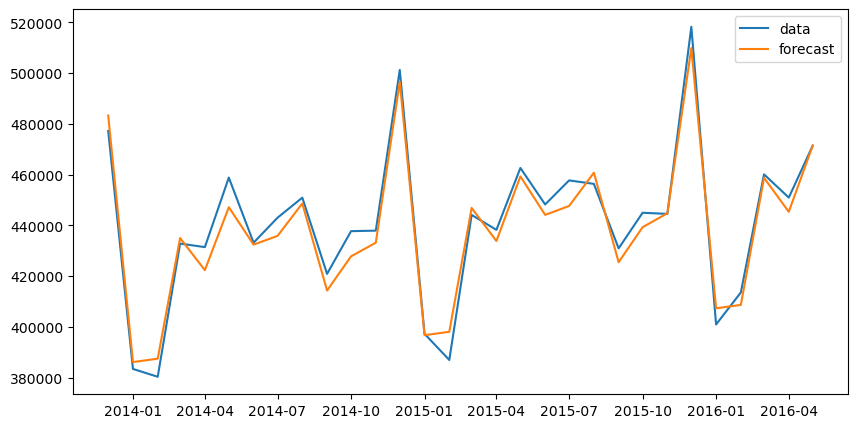

In [49]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(test.index, test, label='data')
ax.plot(test.index, res_hw.forecast(Ntest), label='forecast')
ax.legend();

In [50]:
r2_score(test , res_hw.forecast(Ntest)), r2_score(train , res_hw.fittedvalues)

(0.9619706979959661, 0.993617198377547)